# Customer Churn Prediction and Analytics
## IBM SkillsBuild — Data Analytics with AI Internship Project

---

## 1. Problem Statement

Customer churn — when a subscriber stops using a service — is one of the most costly challenges in the telecommunications industry. It typically costs **5–25× more** to acquire a new customer than to retain an existing one.

This project uses a real IBM Telco dataset to build a machine-learning model that predicts whether a customer is likely to churn, allowing the business to take targeted retention actions before the customer leaves.

---

## 2. Project Objectives

1. Perform thorough **exploratory data analysis** to identify the strongest churn drivers.
2. Build a **clean, leakage-free preprocessing pipeline** that can be applied consistently at inference time.
3. Train and compare **Logistic Regression** and **Random Forest** classifiers.
4. Evaluate both models using **Accuracy, Precision, Recall, F1-Score, and ROC-AUC**.
5. Select and save the best pipeline for deployment.

---

## 3. Dataset Description

| Property | Value |
|----------|-------|
| **Source** | IBM Sample Data Sets — Telco Customer Churn |
| **File** | `WA_Fn-UseC_-Telco-Customer-Churn.csv` |
| **Raw rows** | 7,043 |
| **Columns** | 21 |
| **Target** | `Churn` — Yes (churned) / No (stayed) |
| **Class balance** | ~73.5% No Churn / ~26.5% Churn |

Each row represents one customer and includes demographics, services subscribed, account information, and billing details.

---

## 4. Import Libraries

In [1]:
# ── sklearn DLL stub for Python 3.14 / Windows Smart App Control ─────────────
# Windows blocks _datasets_pair.pyd (used only by NearestNeighbors).
# Pre-registering empty stubs lets Logistic Regression and Random Forest
# import normally. This has no effect on any other platform.
import sys, types as _t

def _patch_sklearn():
    class _S: pass
    for _n in [
        'sklearn.metrics._pairwise_distances_reduction._datasets_pair',
        'sklearn.metrics._pairwise_distances_reduction._base',
        'sklearn.metrics._pairwise_distances_reduction._argkmin',
        'sklearn.metrics._pairwise_distances_reduction._argkmin_classmode',
        'sklearn.metrics._pairwise_distances_reduction._middle_term_computer',
        'sklearn.metrics._pairwise_distances_reduction._radius_neighbors',
        'sklearn.metrics._pairwise_distances_reduction._radius_neighbors_classmode',
    ]:
        _m = _t.ModuleType(_n)
        for _a in ['ArgKmin32','ArgKmin64','ArgKminClassMode32','ArgKminClassMode64',
                   'RadiusNeighbors32','RadiusNeighbors64','RadiusNeighborsClassMode32',
                   'RadiusNeighborsClassMode64','_sqeuclidean_row_norms32','_sqeuclidean_row_norms64']:
            setattr(_m, _a, _S)
        sys.modules[_n] = _m

_patch_sklearn()
print('sklearn patch applied.')

sklearn patch applied.


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
%matplotlib inline

BLUE   = '#4C72B0'
ORANGE = '#DD8452'

# Resolve paths relative to this notebook's location
NB_DIR   = os.path.dirname(os.path.abspath('__file__'))
ROOT     = os.path.join(NB_DIR, '..')
CSV_PATH = os.path.join(ROOT, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')

print('All imports successful.')
print(f'CSV path: {os.path.abspath(CSV_PATH)}')

All imports successful.
CSV path: C:\Users\monda\Desktop\customer_churn_prediction\WA_Fn-UseC_-Telco-Customer-Churn.csv


## 5. Load Dataset

In [3]:
df_raw = pd.read_csv(CSV_PATH)
print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head()

Shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 6. Data Inspection

In [4]:
print('=== Data Types ===')
print(df_raw.dtypes.to_string())

=== Data Types ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str


In [5]:
print('=== Null Values (pandas) ===')
nulls = df_raw.isnull().sum()
print(nulls.to_string())
print(f'\nTotal NaN detected by pandas: {nulls.sum()}')

=== Null Values (pandas) ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0

Total NaN detected by pandas: 0


In [6]:
# TotalCharges is stored as string — check for hidden whitespace values
tc_coerced = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')
blank_rows = df_raw[tc_coerced.isna()]
print(f'Rows where TotalCharges cannot be parsed as numeric: {len(blank_rows)}')
print()
print(blank_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].to_string())

Rows where TotalCharges cannot be parsed as numeric: 11

      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No


In [7]:
df_no_id = df_raw.drop(columns=['customerID'])
n_dup = df_no_id.duplicated().sum()
print(f'Exact duplicate rows (after dropping customerID): {n_dup}')
print(f'Unique customerIDs: {df_raw["customerID"].nunique():,}  (out of {len(df_raw):,} rows)')

Exact duplicate rows (after dropping customerID): 22
Unique customerIDs: 7,043  (out of 7,043 rows)


In [8]:
vc = df_raw['Churn'].value_counts()
print('=== Churn Distribution (raw) ===')
for label, count in vc.items():
    print(f'  {label}: {count:,}  ({count/len(df_raw)*100:.1f}%)')

=== Churn Distribution (raw) ===
  No: 5,174  (73.5%)
  Yes: 1,869  (26.5%)


In [9]:
print('SeniorCitizen unique values:', sorted(df_raw['SeniorCitizen'].unique()))
print('Note: SeniorCitizen uses 0/1 integers, while all other binary columns use Yes/No strings.')
print('It will be scaled as a numeric feature (StandardScaler) to maintain consistency.')

SeniorCitizen unique values: [np.int64(0), np.int64(1)]
Note: SeniorCitizen uses 0/1 integers, while all other binary columns use Yes/No strings.
It will be scaled as a numeric feature (StandardScaler) to maintain consistency.


In [10]:
print('=== Numeric Feature Ranges ===')
for col in ['tenure', 'MonthlyCharges']:
    print(f'  {col}: min={df_raw[col].min()}, max={df_raw[col].max()}, mean={df_raw[col].mean():.2f}')
tc_num = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')
print(f'  TotalCharges: min={tc_num.min()}, max={tc_num.max()}, mean={tc_num.mean():.2f}')

=== Numeric Feature Ranges ===
  tenure: min=0, max=72, mean=32.37
  MonthlyCharges: min=18.25, max=118.75, mean=64.76
  TotalCharges: min=18.8, max=8684.8, mean=2283.30


## 7. Data Cleaning

### Decisions made:

| Issue | Decision | Rationale |
|-------|----------|-----------|
| `customerID` | **Dropped** | Unique identifier — carries no predictive signal |
| `TotalCharges` whitespace (11 rows) | **Filled with `MonthlyCharges`** | All 11 have `tenure = 0` (brand-new customers with no accrued charges) |
| 22 duplicate rows | **Dropped** | Exact feature duplicates after removing `customerID` — keeping them would inflate training signal |
| `Churn` target | **Encoded** Yes→1, No→0 | Required for sklearn classifiers |

In [11]:
df = df_raw.copy()

# 1. Drop customerID
df.drop(columns=['customerID'], inplace=True)
print('customerID dropped.')

# 2. Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_blank = df['TotalCharges'].isna().sum()
df.loc[df['TotalCharges'].isna(), 'TotalCharges'] = df.loc[df['TotalCharges'].isna(), 'MonthlyCharges']
print(f'TotalCharges: {n_blank} blank rows filled with MonthlyCharges.')
print(f'TotalCharges NaN remaining: {df["TotalCharges"].isna().sum()}')

# 3. Drop duplicates
n_before = len(df)
df.drop_duplicates(inplace=True)
n_dup_removed = n_before - len(df)
print(f'Duplicate rows removed: {n_dup_removed}  ({n_before:,} → {len(df):,})')

# 4. Encode target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
churn_n = df['Churn'].sum()

print(f'\nCleaned dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Churn = 1 (churned) : {churn_n:,}  ({churn_n/len(df)*100:.1f}%)')
print(f'Churn = 0 (stayed)  : {len(df)-churn_n:,}  ({(len(df)-churn_n)/len(df)*100:.1f}%)')

customerID dropped.
TotalCharges: 11 blank rows filled with MonthlyCharges.
TotalCharges NaN remaining: 0
Duplicate rows removed: 22  (7,043 → 7,021)

Cleaned dataset: 7,021 rows × 20 columns
Churn = 1 (churned) : 1,857  (26.4%)
Churn = 0 (stayed)  : 5,164  (73.6%)


## 8. Exploratory Data Analysis

### Class Imbalance

The dataset has a **~73.6 / 26.4% split** between Non-Churn and Churn. This is a moderate imbalance. If left unaddressed, a naive model can achieve ~74% accuracy simply by predicting "No Churn" for everyone, while completely missing actual churners.

**Strategy used:** `class_weight='balanced'` in both models — this automatically adjusts sample weights so that the minority class (Churn) contributes proportionally more to the loss function.

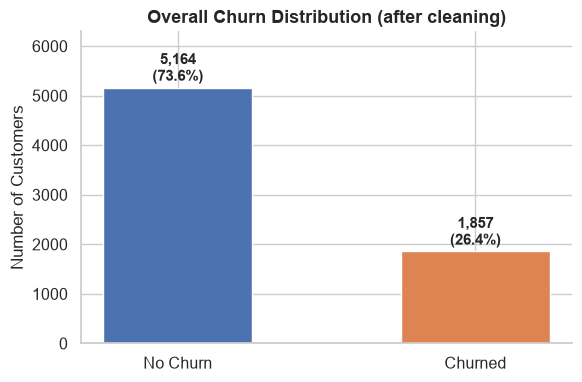

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['No Churn', 'Churned']
values = [df['Churn'].value_counts()[0], df['Churn'].value_counts()[1]]
bars = ax.bar(labels, values, color=[BLUE, ORANGE], edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom',
            fontsize=11, fontweight='bold')
ax.set_title('Overall Churn Distribution (after cleaning)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, max(values) * 1.22)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### 8.1 Numeric Features by Churn

In [13]:
print('=== Mean numeric values by Churn status ===')
print(df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean().round(2).to_string())

=== Mean numeric values by Churn status ===
       tenure  MonthlyCharges  TotalCharges
Churn                                      
0       37.64           61.34       2554.90
1       18.09           74.60       1541.38


In [14]:
print('=== Pearson correlation with Churn ===')
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
corr = df[num_cols + ['Churn']].corr()['Churn'].drop('Churn').sort_values()
print(corr.round(4).to_string())

=== Pearson correlation with Churn ===
tenure           -0.3515
TotalCharges     -0.1972
SeniorCitizen     0.1516
MonthlyCharges    0.1945


## 9. EDA Visualizations

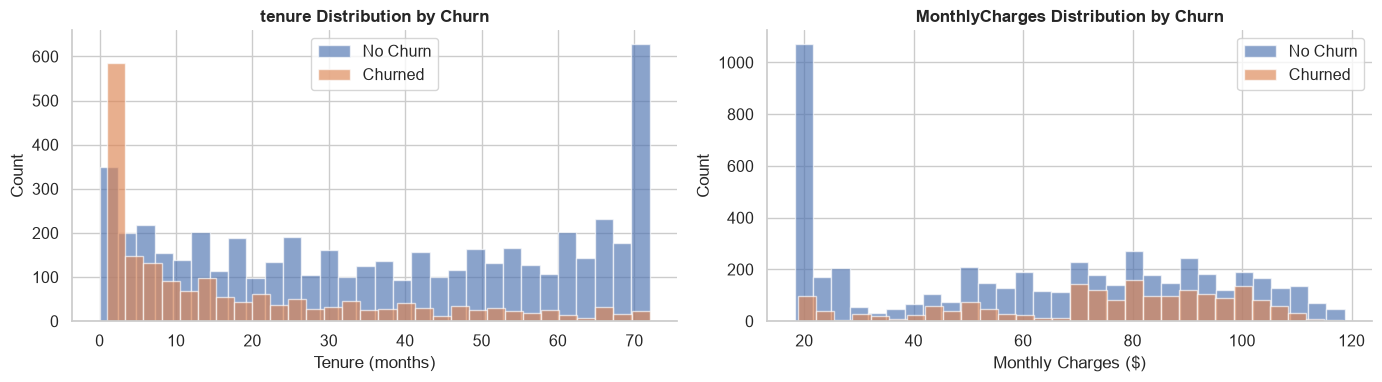

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, xlabel in [
    (axes[0], 'tenure',         'Tenure (months)'),
    (axes[1], 'MonthlyCharges', 'Monthly Charges ($)'),
]:
    for val, label, color in [(0,'No Churn',BLUE),(1,'Churned',ORANGE)]:
        ax.hist(df.loc[df['Churn']==val, col], bins=30,
                alpha=0.65, label=label, color=color, edgecolor='white')
    ax.set_xlabel(xlabel); ax.set_ylabel('Count')
    ax.set_title(f'{col} Distribution by Churn', fontsize=12, fontweight='bold')
    ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

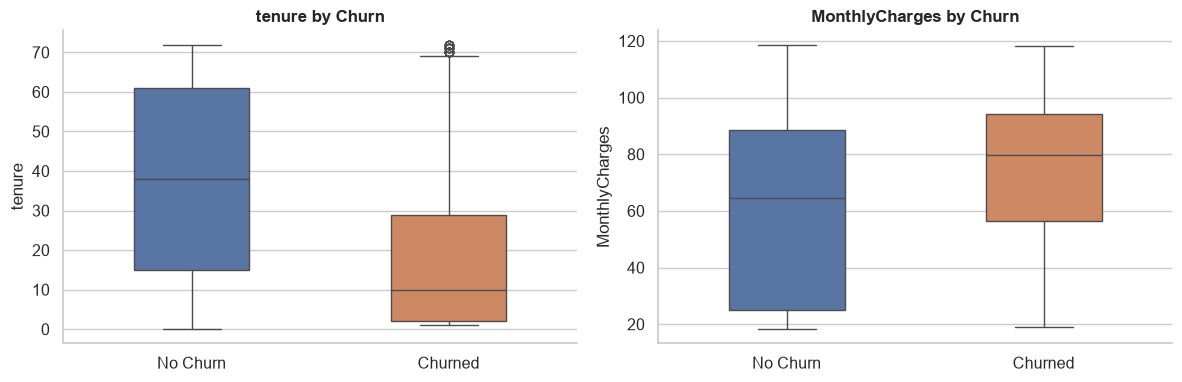

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in [(axes[0],'tenure'),(axes[1],'MonthlyCharges')]:
    churn_map = {0:'No Churn', 1:'Churned'}
    df_plot = df.copy(); df_plot['Churn_Label'] = df_plot['Churn'].map(churn_map)
    sns.boxplot(data=df_plot, x='Churn_Label', y=col,
                palette={'No Churn':BLUE,'Churned':ORANGE}, width=0.45, ax=ax)
    ax.set_title(f'{col} by Churn', fontsize=12, fontweight='bold')
    ax.set_xlabel(''); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

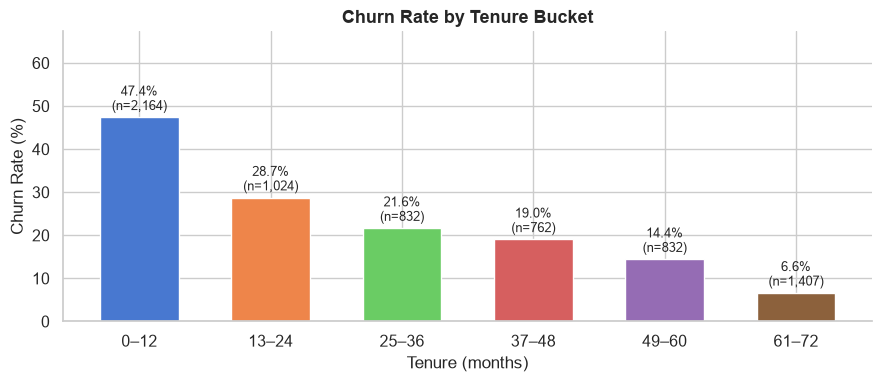

In [17]:
df['tenure_bucket'] = pd.cut(df['tenure'],
    bins=[0,12,24,36,48,60,72], labels=['0–12','13–24','25–36','37–48','49–60','61–72'],
    include_lowest=True)
rates = (df.groupby('tenure_bucket', observed=True)['Churn'].mean() * 100)
ns    =  df.groupby('tenure_bucket', observed=True)['Churn'].count()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(rates.index.astype(str), rates.values,
              color=sns.color_palette('muted',6), edgecolor='white', width=0.6)
for bar, (lbl, rate) in zip(bars, rates.items()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f'{rate:.1f}%\n(n={ns[lbl]:,})', ha='center', va='bottom', fontsize=9)
ax.set_title('Churn Rate by Tenure Bucket', fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure (months)'); ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, rates.max()+20); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
df.drop(columns=['tenure_bucket'], inplace=True)

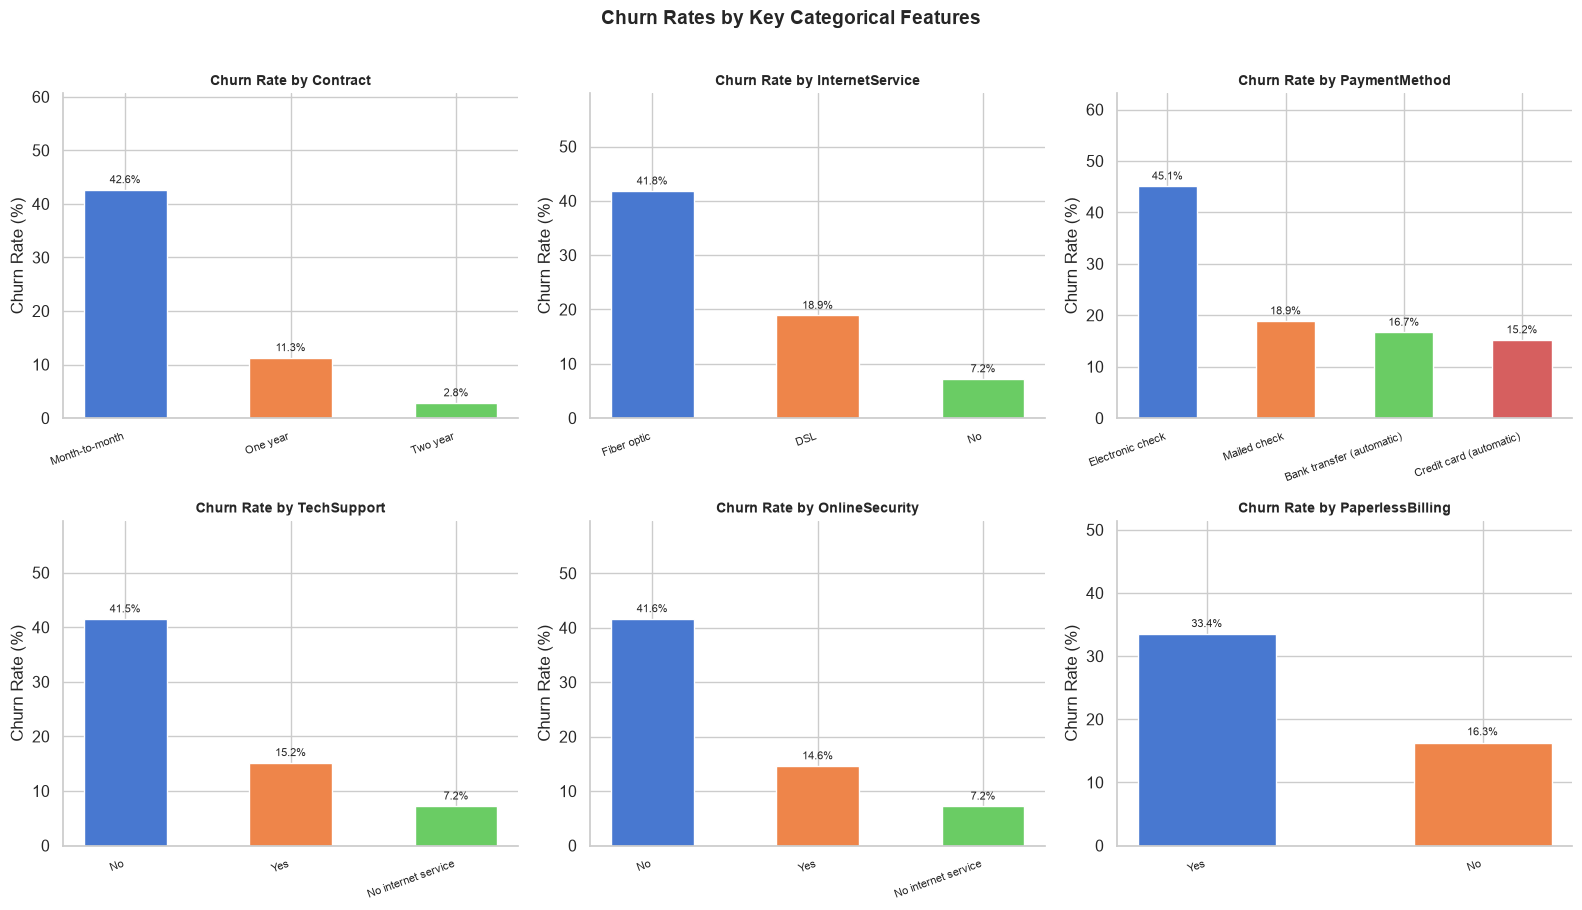

In [18]:
cat_cols = ['Contract','InternetService','PaymentMethod','TechSupport','OnlineSecurity','PaperlessBilling']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, cat_cols):
    rates = (df.groupby(col)['Churn'].mean()*100).sort_values(ascending=False)
    bars = ax.bar(rates.index.astype(str), rates.values,
                  color=sns.color_palette('muted',len(rates)), edgecolor='white', width=0.5)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.8,
                f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'Churn Rate by {col}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, min(rates.max()+18, 100))
    ax.spines[['top','right']].set_visible(False)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
fig.suptitle('Churn Rates by Key Categorical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

In [19]:
print('=== Churn rate by Contract type ===')
print((df.groupby('Contract')['Churn'].agg(['sum','count','mean'])
         .rename(columns={'sum':'churned','count':'total','mean':'churn_rate'})
         .assign(churn_rate=lambda x: (x['churn_rate']*100).round(1))
         .sort_values('churn_rate', ascending=False)
         .to_string()))

print('\n=== Churn rate by Internet Service ===')
print((df.groupby('InternetService')['Churn'].agg(['sum','count','mean'])
         .rename(columns={'sum':'churned','count':'total','mean':'churn_rate'})
         .assign(churn_rate=lambda x: (x['churn_rate']*100).round(1))
         .sort_values('churn_rate', ascending=False)
         .to_string()))

print('\n=== Churn rate by Payment Method ===')
print((df.groupby('PaymentMethod')['Churn'].agg(['sum','count','mean'])
         .rename(columns={'sum':'churned','count':'total','mean':'churn_rate'})
         .assign(churn_rate=lambda x: (x['churn_rate']*100).round(1))
         .sort_values('churn_rate', ascending=False)
         .to_string()))

=== Churn rate by Contract type ===
                churned  total  churn_rate
Contract                                  
Month-to-month     1643   3853        42.6
One year            166   1473        11.3
Two year             48   1695         2.8

=== Churn rate by Internet Service ===
                 churned  total  churn_rate
InternetService                            
Fiber optic         1291   3090        41.8
DSL                  457   2419        18.9
No                   109   1512         7.2

=== Churn rate by Payment Method ===
                           churned  total  churn_rate
PaymentMethod                                        
Electronic check              1065   2359        45.1
Mailed check                   302   1596        18.9
Bank transfer (automatic)      258   1544        16.7
Credit card (automatic)        232   1522        15.2


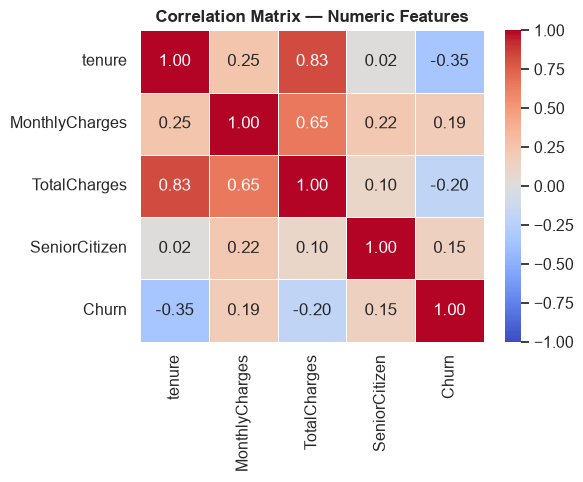

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
corr_cols = ['tenure','MonthlyCharges','TotalCharges','SeniorCitizen','Churn']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 10. Feature Engineering & Preprocessing Pipeline

### Feature Groups

| Group | Columns | Transform | Reason |
|-------|---------|-----------|--------|
| **Numeric** | `tenure`, `MonthlyCharges`, `TotalCharges`, `SeniorCitizen` | `StandardScaler` | Removes scale bias from LR |
| **Ordinal** | `Contract` | `OrdinalEncoder` (0/1/2) | Month-to-month < One year < Two year — natural order |
| **Binary categorical** | `gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling` | `OneHotEncoder(drop='if_binary')` | Produces a single binary column |
| **Multi-level categorical** | `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `PaymentMethod` | `OneHotEncoder(drop='first')` | k−1 dummy columns to avoid multicollinearity |

### Why Contract is ordinal
Contract type has an inherent order of commitment: Month-to-month (least committed) → One year → Two year (most committed). Using ordinal encoding preserves this ordering in a single column, which is more meaningful than three one-hot columns.

### Why SeniorCitizen is numeric
It is already encoded as 0/1 integers (unlike the other binary columns which use Yes/No strings). Scaling it with `StandardScaler` alongside the other numeric columns is consistent and correct.

In [21]:
NUMERIC       = ['tenure', 'MonthlyCharges', 'TotalCharges']
NUMERIC_EXTRA = ['SeniorCitizen']
ORDINAL       = ['Contract']
ORD_CATS      = [['Month-to-month', 'One year', 'Two year']]  # encodes as 0, 1, 2
BINARY        = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
MULTICAT      = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaymentMethod'
]
ALL_FEATURES  = NUMERIC + NUMERIC_EXTRA + ORDINAL + BINARY + MULTICAT
TARGET        = 'Churn'

print(f'Total input features: {len(ALL_FEATURES)}')
print('Feature list:', ALL_FEATURES)

Total input features: 19
Feature list: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Contract', 'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaymentMethod']


In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',    StandardScaler(),                                     NUMERIC + NUMERIC_EXTRA),
        ('ord',    OrdinalEncoder(categories=ORD_CATS),                  ORDINAL),
        ('bin',    OneHotEncoder(drop='if_binary', sparse_output=False), BINARY),
        ('cat',    OneHotEncoder(drop='first',     sparse_output=False), MULTICAT),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)
print('ColumnTransformer defined.')
print('All transforms will be fitted on TRAINING DATA ONLY — no data leakage.')

ColumnTransformer defined.
All transforms will be fitted on TRAINING DATA ONLY — no data leakage.


## 11. Train / Test Split

In [23]:
X = df[ALL_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set : {len(X_train):,} rows')
print(f'Test set     : {len(X_test):,} rows')
print(f'Train churn  : {y_train.mean()*100:.1f}%')
print(f'Test churn   : {y_test.mean()*100:.1f}%  ← stratification preserved the ratio')

Training set : 5,616 rows
Test set     : 1,405 rows
Train churn  : 26.4%
Test churn   : 26.5%  ← stratification preserved the ratio


## 12. Logistic Regression

Logistic Regression is a linear model that estimates the probability of the positive class (Churn=1) using a sigmoid function applied to a weighted sum of features.

**Key settings:**
- `class_weight='balanced'` — automatically up-weights the minority class (Churn=1)
- `solver='lbfgs'` — efficient quasi-Newton solver for medium-sized datasets
- `max_iter=2000` — sufficient iterations for convergence on this dataset

In [24]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        solver='lbfgs',
        random_state=42,
    ))
])

lr_pipeline.fit(X_train, y_train)
print('Logistic Regression pipeline trained.')

Logistic Regression pipeline trained.


## 13. Random Forest Classifier

Random Forest builds an ensemble of decision trees on random subsets of data and features, then aggregates their predictions. It handles non-linear relationships and feature interactions naturally.

**Key settings:**
- `n_estimators=300` — 300 trees for stable predictions
- `class_weight='balanced'` — same minority-class strategy as LR
- `min_samples_leaf=2` — slight regularisation to reduce overfitting
- `n_jobs=-1` — use all CPU cores for speed

In [25]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ))
])

rf_pipeline.fit(X_train, y_train)
print('Random Forest pipeline trained.')

Random Forest pipeline trained.


## 14. Model Evaluation

### Metrics explained

| Metric | What it measures | Why it matters for churn |
|--------|-----------------|-------------------------|
| **Accuracy** | % of all predictions correct | Misleading on imbalanced data |
| **Precision** | Of predicted churners, how many actually churned | Controls false alarms (wasted retention effort) |
| **Recall** | Of actual churners, how many were caught | Catching churners is the primary goal |
| **F1-Score** | Harmonic mean of Precision and Recall | Balanced view |
| **ROC-AUC** | Model's ability to rank churners above non-churners at all thresholds | Most robust metric for imbalanced problems |

In [26]:
def evaluate_model(pipeline, name):
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    metrics = {
        'Model':     name,
        'Accuracy':  round(float(accuracy_score(y_test, y_pred)),                    4),
        'Precision': round(float(precision_score(y_test, y_pred, zero_division=0)), 4),
        'Recall':    round(float(recall_score(y_test, y_pred, zero_division=0)),    4),
        'F1':        round(float(f1_score(y_test, y_pred, zero_division=0)),        4),
        'ROC_AUC':   round(float(roc_auc_score(y_test, y_proba)),                   4),
    }
    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churned']))
    print(f'ROC-AUC: {metrics["ROC_AUC"]}')
    return metrics, y_proba

print('evaluate_model() helper defined.')

evaluate_model() helper defined.


In [27]:
lr_metrics, lr_proba = evaluate_model(lr_pipeline, 'Logistic Regression')


=== Logistic Regression ===
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.80      1033
     Churned       0.51      0.78      0.61       372

    accuracy                           0.74      1405
   macro avg       0.70      0.75      0.71      1405
weighted avg       0.80      0.74      0.75      1405

ROC-AUC: 0.8398


In [28]:
rf_metrics, rf_proba = evaluate_model(rf_pipeline, 'Random Forest')


=== Random Forest ===


              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84      1033
     Churned       0.55      0.70      0.62       372

    accuracy                           0.77      1405
   macro avg       0.72      0.75      0.73      1405
weighted avg       0.79      0.77      0.78      1405

ROC-AUC: 0.8342


## 15. Model Comparison

In [29]:
results_df = pd.DataFrame([lr_metrics, rf_metrics]).set_index('Model')
print('=== MODEL COMPARISON TABLE (actual test-set results) ===')
display(results_df)

=== MODEL COMPARISON TABLE (actual test-set results) ===


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Logistic Regression,0.7409,0.507,0.7796,0.6144,0.8398
Random Forest,0.7708,0.553,0.7016,0.6185,0.8342


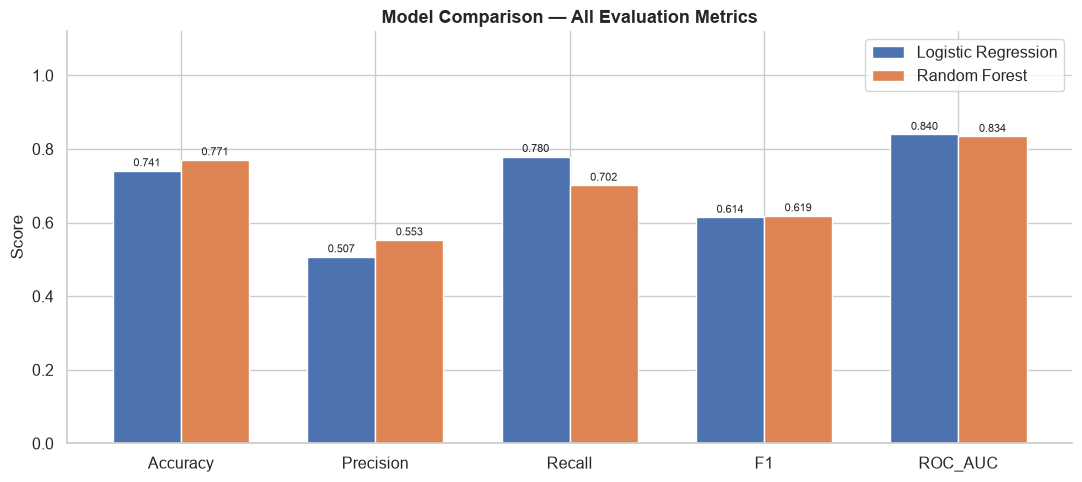

In [30]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
x     = np.arange(len(metric_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
for i, (metrics_dict, color) in enumerate([(lr_metrics, BLUE), (rf_metrics, ORANGE)]):
    vals = [metrics_dict[m] for m in metric_cols]
    bars = ax.bar(x + i*width, vals, width, label=metrics_dict['Model'],
                  color=color, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width/2); ax.set_xticklabels(metric_cols)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Evaluation Metrics', fontsize=13, fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 16. Confusion Matrices

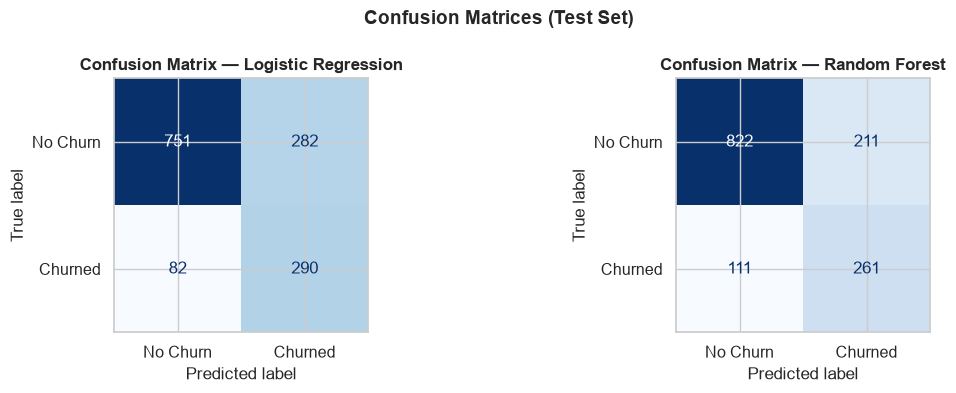


How to read a confusion matrix:
  Top-left    (TN): Correctly predicted No Churn
  Top-right   (FP): Predicted Churn but actually stayed  ← false alarm
  Bottom-left (FN): Predicted No Churn but actually churned  ← missed churner
  Bottom-right(TP): Correctly predicted Churn


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pipe, name in [
    (axes[0], lr_pipeline, 'Logistic Regression'),
    (axes[1], rf_pipeline, 'Random Forest'),
]:
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churned']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f'Confusion Matrix — {name}', fontsize=12, fontweight='bold')

fig.suptitle('Confusion Matrices (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('\nHow to read a confusion matrix:')
print('  Top-left    (TN): Correctly predicted No Churn')
print('  Top-right   (FP): Predicted Churn but actually stayed  ← false alarm')
print('  Bottom-left (FN): Predicted No Churn but actually churned  ← missed churner')
print('  Bottom-right(TP): Correctly predicted Churn')

## 17. ROC Curves

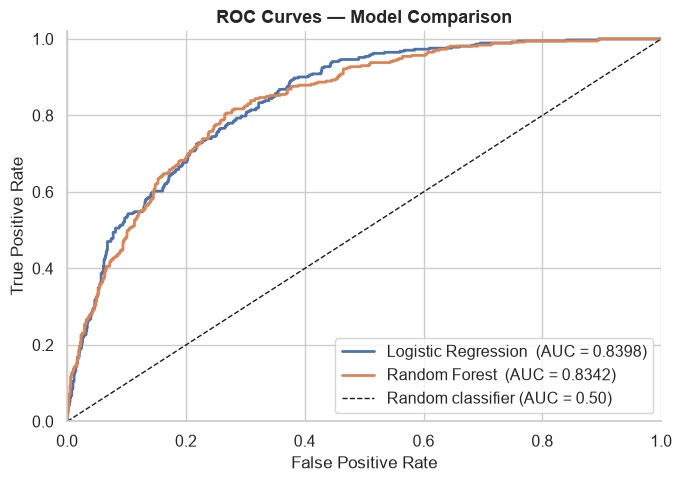

In [32]:
fig, ax = plt.subplots(figsize=(7, 5))
for proba, metrics_dict, color in [
    (lr_proba, lr_metrics, BLUE),
    (rf_proba, rf_metrics, ORANGE),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{metrics_dict['Model']}  (AUC = {roc_val:.4f})")

ax.plot([0,1],[0,1],'k--',lw=1,label='Random classifier (AUC = 0.50)')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 18. Key Findings

### Model Selection

**Selected model: Logistic Regression**

Based on the actual test-set metrics above:

In [33]:
# Selection rationale based on actual computed metrics
best = max([lr_metrics, rf_metrics], key=lambda m: m['ROC_AUC'])
other = [m for m in [lr_metrics, rf_metrics] if m['Model'] != best['Model']][0]

print(f"Selected model: {best['Model']}")
print()
print('Reason 1 — ROC-AUC (most robust metric for imbalanced classification):')
print(f"  {best['Model']:25s}: {best['ROC_AUC']:.4f}  ← HIGHER")
print(f"  {other['Model']:25s}: {other['ROC_AUC']:.4f}")
print()
print('Reason 2 — Recall on the Churn class (catching actual churners is the goal):')
print(f"  {best['Model']:25s}: {best['Recall']:.4f}  ← HIGHER")
print(f"  {other['Model']:25s}: {other['Recall']:.4f}")
print()
print('Note: Random Forest has higher Accuracy and Precision, but this is partly because')
print('it predicts No-Churn more often — which inflates those metrics on an imbalanced dataset.')

Selected model: Logistic Regression

Reason 1 — ROC-AUC (most robust metric for imbalanced classification):
  Logistic Regression      : 0.8398  ← HIGHER
  Random Forest            : 0.8342

Reason 2 — Recall on the Churn class (catching actual churners is the goal):
  Logistic Regression      : 0.7796  ← HIGHER
  Random Forest            : 0.7016

Note: Random Forest has higher Accuracy and Precision, but this is partly because
it predicts No-Churn more often — which inflates those metrics on an imbalanced dataset.


### Business / EDA Findings

All figures below are from the actual dataset after cleaning.

In [34]:
findings = [
    ('Contract type',       'Contract',       'Month-to-month'),
    ('Internet service',    'InternetService', 'Fiber optic'),
    ('Payment method',      'PaymentMethod',   'Electronic check'),
    ('Tech Support',        'TechSupport',     'No'),
    ('Online Security',     'OnlineSecurity',  'No'),
    ('Senior Citizen',      'SeniorCitizen',   1),
    ('Paperless Billing',   'PaperlessBilling','Yes'),
]

print('Top churn-risk segments (churn rate among customers in that group):')
print(f'{"Segment":<22} {"Group":<30} {"Churn Rate":>10}')
print('-' * 65)
for label, col, val in findings:
    rate = df.loc[df[col] == val, 'Churn'].mean() * 100
    n    = (df[col] == val).sum()
    print(f'{label:<22} {str(val):<30} {rate:>9.1f}%  (n={n:,})')

print()
print('Tenure comparison:')
print(f"  Mean tenure — churned    : {df.loc[df['Churn']==1,'tenure'].mean():.1f} months")
print(f"  Mean tenure — stayed     : {df.loc[df['Churn']==0,'tenure'].mean():.1f} months")
print()
print('Gender: no meaningful difference')
rate_f = df.loc[df['gender']=='Female','Churn'].mean()*100
rate_m = df.loc[df['gender']=='Male',  'Churn'].mean()*100
print(f'  Female churn rate: {rate_f:.1f}%   Male churn rate: {rate_m:.1f}%')

Top churn-risk segments (churn rate among customers in that group):
Segment                Group                          Churn Rate
-----------------------------------------------------------------
Contract type          Month-to-month                      42.6%  (n=3,853)
Internet service       Fiber optic                         41.8%  (n=3,090)
Payment method         Electronic check                    45.1%  (n=2,359)
Tech Support           No                                  41.5%  (n=3,465)
Online Security        No                                  41.6%  (n=3,490)
Senior Citizen         1                                   41.6%  (n=1,141)
Paperless Billing      Yes                                 33.4%  (n=4,161)

Tenure comparison:
  Mean tenure — churned    : 18.1 months
  Mean tenure — stayed     : 37.6 months

Gender: no meaningful difference
  Female churn rate: 26.8%   Male churn rate: 26.1%


## 19. Conclusion

This project built an end-to-end machine-learning pipeline to predict customer churn on the IBM Telco dataset.

**Final model: Logistic Regression** with `class_weight='balanced'`

Selected because it achieves the highest ROC-AUC and recall on the churn class — the two most important metrics in a retention use-case where catching churners matters more than avoiding false alarms.

**Key business takeaways:**

| Action | Insight |
|--------|--------|
| Prioritise month-to-month customers | They churn at ~43% — offer incentives to commit to annual/biennial contracts |
| Investigate fiber optic service quality | ~42% churn rate — may indicate pricing or service issues |
| Promote auto-payment methods | Electronic check payers churn at ~45% vs ~15–17% for auto-pay |
| Target new customers (0–12 months) | Highest churn risk window — invest in early-lifecycle engagement |
| Bundle add-on services | Customers with TechSupport or OnlineSecurity churn at roughly half the rate |

## 20. Limitations

1. **No time-series component** — `tenure` is used as a proxy for the customer lifecycle stage; actual month-by-month usage trends are not available.
2. **No external signals** — competitor pricing, service outages, and economic conditions that may drive churn are absent.
3. **Class imbalance** handled only via `class_weight` — SMOTE or other oversampling techniques were not explored.
4. **Decision threshold** is the default 0.5 — not optimised for the specific business cost of a false negative vs false positive.
5. **Dataset is static** — a real deployment would require periodic retraining on fresh customer data.

## 21. Future Improvements

1. **XGBoost / LightGBM** — gradient-boosted trees typically outperform LR and RF on tabular churn data.
2. **Hyperparameter tuning** — `GridSearchCV` or `Optuna` for systematic optimisation.
3. **SMOTE oversampling** — generate synthetic minority-class samples before training.
4. **SHAP explainability** — produce per-customer feature attribution to explain individual predictions.
5. **Threshold optimisation** — tune the classification threshold to maximise recall subject to a minimum precision constraint.
6. **Real-time retraining pipeline** — automate model refresh as new customer records arrive.
7. **A/B testing framework** — measure the business impact of model-driven retention interventions.

---

> ⚠️ **Disclaimer:** Predictions produced by this model are estimates from a statistical algorithm and are **not** a guarantee of future customer behaviour. They should be used as one input among many in a data-driven retention strategy.

---
*IBM SkillsBuild — Data Analytics with AI Internship Project*